# Exercício Prático - GAN

## SCC5809 - REDES NEURAIS ARTIFICIAIS E APRENDIZADO PROFUNDO
## **SCC - ICMC - USP**
Profa. Roseli Ap. Francelin Romero </br>
2o. sem. de 2024 </br>

### Grupo
- Diogo Castanho Emídio (11297274)
- Julyana Flores de Prá (15600911)
- Thiago Rafael Mariotti Claudio (15611674)

# **Exercício de Rede GAN usando CNNs** nos módulos:

. Modelo Discriminador <br>
. Modelo Generativo para geração de imagens (conjunto MNIST)

## Setup

In [1]:
%pip install imageio
%pip install git+https://github.com/tensorflow/docs

Note: you may need to restart the kernel to use updated packages.
  Cloning https://github.com/tensorflow/docs to /tmp/pip-req-build-ex6tun2w
  Running command git clone --filter=blob:none --quiet https://github.com/tensorflow/docs /tmp/pip-req-build-ex6tun2w
  Resolved https://github.com/tensorflow/docs to commit a45eae2e4cd45ed2593793d1cdb4ed6990a807e9
  Preparing metadata (setup.py) ... done
  Using cached PyYAML-6.0.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.1 kB)
Using cached PyYAML-6.0.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (767 kB)
  Created wheel for tensorflow-docs: filename=tensorflow_docs-2024.7.15.51478-py3-none-any.whl size=182585 sha256=13bdfe12b3d76b267c0dd7088fb8895878496f791833355278bfff201814eccc
  Stored in directory: /tmp/pip-ephem-wheel-cache-w6djt7jo/wheels/3e/88/34/48d2789bc9d37b33ddce06bccc454fae0285e5396d0a5be9d9
Successfully built tensorflow-docs
Note: you may need to restart the kernel to use updated package

In [2]:
import tensorflow as tf
import glob
import imageio
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
from tensorflow.keras import layers
import time

from IPython import display

2024-10-10 14:04:16.306374: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-10-10 14:04:16.583349: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-10-10 14:04:16.662461: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-10-10 14:04:17.196945: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-10 14:04:21.494497: W tensorflow/compiler/tf2

### Carregando e pré-processando o dataset

Será utilizado o dataset MNIST para que seja treinado o modelo gerador e o discriminador.

In [ ]:
# Carregando o dataset
(train_images, train_labels), (_, _) = tf.keras.datasets.mnist.load_data()

Em passos futuros, vamos utilizar de ruídos aleatórios dados por uma distribuição normal entre [-1, 1]. Portanto, temos que nosso dataset também deve ser normalizado dessa maneira. Como temos imagens de 8 bits (valores de 0 a 255), vamos utilzar metade do valor total, isto é, 127.5, para normalizarmos os dados. Temos, portanto, a seguinte normalização: $$ \frac{x - 127.5}{127.5} $$
Percebemos que se substituirmos os valores de máximo e mínimo (0 e 255), teremos como resultado, respectivamente, -1 e 1.

In [3]:
# Normalizando o dataset
train_images = train_images.reshape(train_images.shape[0], 28, 28, 1).astype('float32')
train_images = (train_images - 127.5) / 127.5

NameError: name 'train_images' is not defined

In [ ]:
# Variáveis para embaralharmos o dataset e separarmos em batches
BUFFER_SIZE = 60000
BATCH_SIZE = 256

In [ ]:
train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

## Criação dos modelos

Ambos modelos gerador e discriminador são definidos utilizando um modelo sequencial do framework - [Keras Sequential API](https://www.tensorflow.org/guide/keras#sequential_model).

### Modelo Gerador

O modelo gerador utiliza de uma seed aleatória para fazer a imagem. `tf.keras.layers.Conv2DTranspose` faz essa construção. Ao final, devemos obter uma imagem 28x28x1.
Faça um modelo gerador utilizando `tf.keras.Sequential` com os seguintes critérios:
- Para cada camada, utilize o parâmetro  `use_bias=False`.
- Utilize Batch Normalization após cada camada (não necessária na de saída)
- Utilize a função Leaky ReLU como ativação.
- Utilize tanh como função de ativação da última camada.
Siga a seguinte arquitetura:
- Camada densa com $7 \cdot 7 \cdot 256$ com entrada (100,). A entrada será um seed (ruído aleatório) para servir de base para a construção da imagem. Escolhemos essa saída para conseguirmos gerar ao final facilmente uma imagem (28, 28, 1).
- Camada de `Conv2DTranspose` para construir uma imagem. Ela deve possuir 128 filtros (5, 5) aplicando zero-padding.
- Camada de `Conv2DTranspose` para construir uma imagem. Ela deve possuir 64 filtros (5, 5) aplicando zero-padding com stride de (2, 2).
- Camada de saída `Conv2DTranspose` para construir a imagem final. Ela deve possui 1 saída com filtro (5, 5) aplicando zero-padding com stride de (2, 2).


In [4]:
def modelo_gerador():

    use_bias = False

    model = tf.keras.Sequential()
    # TODO: seu código da camada densa
    model.add(layers.Dense(7*7*256, use_bias=use_bias, input_shape=(100,)))
    model.add(layers.Reshape((7, 7, 256)))

    # TODO: seu código das camadas Conv2DTranspose
    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=use_bias))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=use_bias))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=use_bias, activation='tanh'))


    return model

Usando o modelo gerador sem treinamento

/home/rafflezs/Projetos/Atividades-Mestrado-ICMC/DeepLearning/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


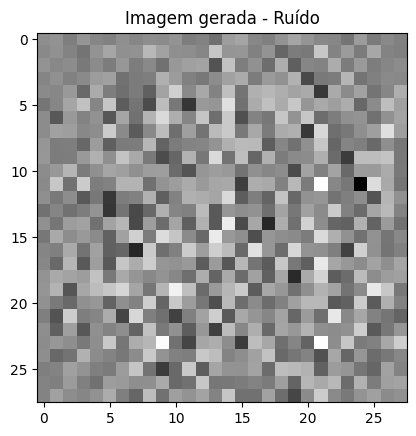

In [6]:
gerador = modelo_gerador()

seed = tf.random.normal([1, 100])
imagem_gerada = gerador(seed, training=False)

plt.title('Imagem gerada - Ruído')
plt.imshow(imagem_gerada[0, :, :, 0], cmap='gray')

### Modelo Discriminador

O modelo discriminador consiste em um classificador de imagem baseado em uma rede neural convolucional.

Na função abaixo, declare um modelo sequencial do keras (`tf.keras.Sequential`) com as seguintes camadas:
- Camada convolucional de input $28 \times 28 \times 1$ (dimensão de cada imagem), com 64 filtros de tamanho $5\times5$, stride de 2 e zero-padding (`padding = 'same'`)
- Função de ativação não linear leaky ReLU
- Dropout com $p = 0.3$
- Camada convolucional com 128 filtros de tamanho $5\times5$, stride de 2 e zero-padding
- Função de ativação não linear leaky ReLU
- Dropout com $p=0.3$
- Flatten dos mapas de características obtidos
- Camada densa de apenas um neurónio

In [7]:
def modelo_discriminador():
    model = tf.keras.Sequential()

    # TODO: seu código aqui
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=[28, 28, 1]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())

    model.add(layers.Dense(1))

    return model

Uma vez com os modelos gerador e discriminador em mãos (e ainda não treinados), podemos classificar as imagens geradas como reais ou falsas.

Iremos treinar o modelo de forma que o resultado positivo indique imagens reais, enquanto valores negativos indiquem imagens falsas.

In [8]:
discriminador = modelo_discriminador()
decision = discriminador(imagem_gerada)
print (decision)

tf.Tensor([[0.00399287]], shape=(1, 1), dtype=float32)


/home/rafflezs/Projetos/Atividades-Mestrado-ICMC/DeepLearning/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Definindo a função de custo e otimizadores

Agora, devemos definir as funções de custo e quais serão os otimizadores para ambos os modelos para que possa ocorrer o treinamento.

In [ ]:
# Função de entropia cruzada para cálculo da loss
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

### Discriminator loss

Com a função abaixo devemos quantificar quão bem o discriminador classifica as imagens reais e/ou imagens falsas.

Para isso, devemos comparar as predições do discriminador para as imagens reais ao array de uns e as predições do discriminador em imagens falsas, criadas pelo nosso modelo gerador, com um array de valores zeros.

Na função, atribua à `fake_loss` a entropia cruzada do output em cima de imagens criadas pelo modelo gerador em relação ao array de valores zeros.

In [ ]:
def discriminador_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)

    fake_loss = None # TODO: defina a fake_loss

    total_loss = real_loss + fake_loss
    return total_loss


### Generator loss

A função de custo do modelo gerador é quantificada a partir do quão confuso foi a predição do modelo discriminador.

Assim, intuitivamente o que temos é que se o modelo gerador é capaz de gerar imagens boas, o discriminador irá classificar imagens falsas (0) como verdadeiras/reais (1), configurando uma baixa loss.

Para realizar a computação desta função de custo, devemos realizar a entropia cruzada entre o array de uns e o array da predição do nosso discriminador para as imagens falsas.

Considerando um array da predição dentro do conjunto de imagens geradas como {0 1 0 1 0 1 0 0 1 0 0 1}, temos

- Número de imagens falsas classificadas como falsas: 7
- Número de imagens falsas classificadas como reais: 5

Ao realizarmos a entropia cruzada com um vetor {1 1 1 1 1 1 1 1 1 1 1 1}, iremos **penalizar para cada um dos zeros que aparecem**, uma vez que indicam uma classificação certa do modelo discriminador.

In [ ]:
def gerador_loss(fake_output):
    return None # TODO: defina a loss do gerador

Vamos definir os otimizadores para cada modelo

In [ ]:
gerador_opt = tf.keras.optimizers.Adam(1e-4)
discriminador_opt = tf.keras.optimizers.Adam(1e-4)

## Loop de treinamento


In [ ]:
epocas = 50
seed_dim = 100
n_exemplos = 16
seed = tf.random.normal([n_exemplos, seed_dim])


Temos que o treinamento começa com o **gerador** recebendo uma seed como input e produzindo uma imagem. Após isso, o discriminador é usado para classificar as imagens do dataset original e as produzidas pelo gerador. Calculamos a **função perda (loss)** de cada modelo e seus gradientes.

In [ ]:
@tf.function
def step_treino(images):
    seed = tf.random.normal([BATCH_SIZE, seed_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
      imagens_geradas = gerador(seed, training=True) # Construindo imagens falsas pelo modelo gerador

      real_output = discriminador(images, training=True) # Previsão do discriminador com imagens reais
      fake_output = discriminador(imagens_geradas, training=True) # Previsão do discriminador com as imagens geradas

      # TODO
      gen_loss = None # Calcule a loss do gerador
      disc_loss = None # Calcule a loss do discriminador

    gradientes_gerador = gen_tape.gradient(gen_loss, gerador.trainable_variables)
    gradientes_discriminador = disc_tape.gradient(disc_loss, discriminador.trainable_variables)

    gerador_opt.apply_gradients(zip(gradientes_gerador, gerador.trainable_variables))
    discriminador_opt.apply_gradients(zip(gradientes_discriminador, discriminador.trainable_variables))

In [ ]:
def treino(dataset, epocas):
  for epoca in range(epocas):
    start = time.time()

    for image_batch in dataset:
      step_treino(image_batch)

    # Produzindo imagens para formarmos um GIF ao final
    display.clear_output(wait=True)
    gerar_imagens(gerador, epoca + 1, seed)

    print ('Tempo de execução para a época {} é {} segundos'.format(epoca + 1, time.time()-start))

  # Salvando imagens para criação do GIF
  display.clear_output(wait=True)
  gerar_imagens(gerador, epocas, seed)

**Função para gerarmos e salvarmos as imagens**


In [ ]:
def gerar_imagens(model, epoca, test_input):
  preds = model(test_input, training=False)

  fig = plt.figure(figsize=(4, 4))

  for i in range(preds.shape[0]):
      plt.subplot(4, 4, i+1)
      plt.imshow(preds[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
      plt.axis('off')

  plt.savefig('imagem_epoca_{:04d}.png'.format(epoca))
  plt.show()

## Treinamento

Chamamos agora a função de treino definida acima para treinar simultaneamente os modelos.

Vamos analisar as imagens geradas cada época.

In [ ]:
treino(train_dataset, epocas)

## Criando um GIF


In [ ]:
def display_image(epoch_no):
  return PIL.Image.open('imagem_epoca_{:04d}.png'.format(epoch_no))

In [ ]:
display_image(epocas)

Vamos usar `imageio` para criar um GIF animado a partir das imagens salvas

In [ ]:
anim_file = 'dcgan.gif'

with imageio.get_writer(anim_file, mode='I') as writer:
  filenames = glob.glob('image*.png')
  filenames = sorted(filenames)
  for filename in filenames:
    image = imageio.imread(filename)
    writer.append_data(image)
  image = imageio.imread(filename)
  writer.append_data(image)

In [ ]:
import tensorflow_docs.vis.embed as embed
embed.embed_file(anim_file)